In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/healthcare_dataset (1).csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34636 entries, 0 to 34635
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                34636 non-null  object 
 1   Age                 34636 non-null  int64  
 2   Gender              34636 non-null  object 
 3   Blood Type          34636 non-null  object 
 4   Medical Condition   34636 non-null  object 
 5   Date of Admission   34636 non-null  object 
 6   Doctor              34636 non-null  object 
 7   Hospital            34636 non-null  object 
 8   Insurance Provider  34636 non-null  object 
 9   Billing Amount      34636 non-null  float64
 10  Room Number         34635 non-null  float64
 11  Admission Type      34635 non-null  object 
 12  Discharge Date      34635 non-null  object 
 13  Medication          34635 non-null  object 
 14  Test Results        34635 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 4.0

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,34636.000000,34636.000000,34635.000000
mean,51.587077,25588.435564,300.579039
std,19.574430,14211.630822,115.235115
min,18.000000,-1316.618581,101.000000
25%,35.000000,13279.808156,201.000000
50%,52.000000,25591.515509,301.000000
75%,69.000000,37874.997382,400.000000
max,85.000000,52373.032374,500.000000


In [8]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [11]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [16]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

df['Year_Month'] = df['Date of Admission'].dt.to_period('M')

In [17]:
monthly_admissions = df.groupby('Year_Month').size()

monthly_admissions.head()

,0
Year_Month,
2019-05,429
2019-06,591
2019-07,589
2019-08,619
2019-09,580


In [19]:
peak_month = monthly_admissions.idxmax()
peak_admissions = monthly_admissions.max()

print("Peak Admission Month:", peak_month)
print("Number of Admissions:", peak_admissions)

Peak Admission Month: 2020-08
Number of Admissions: 658


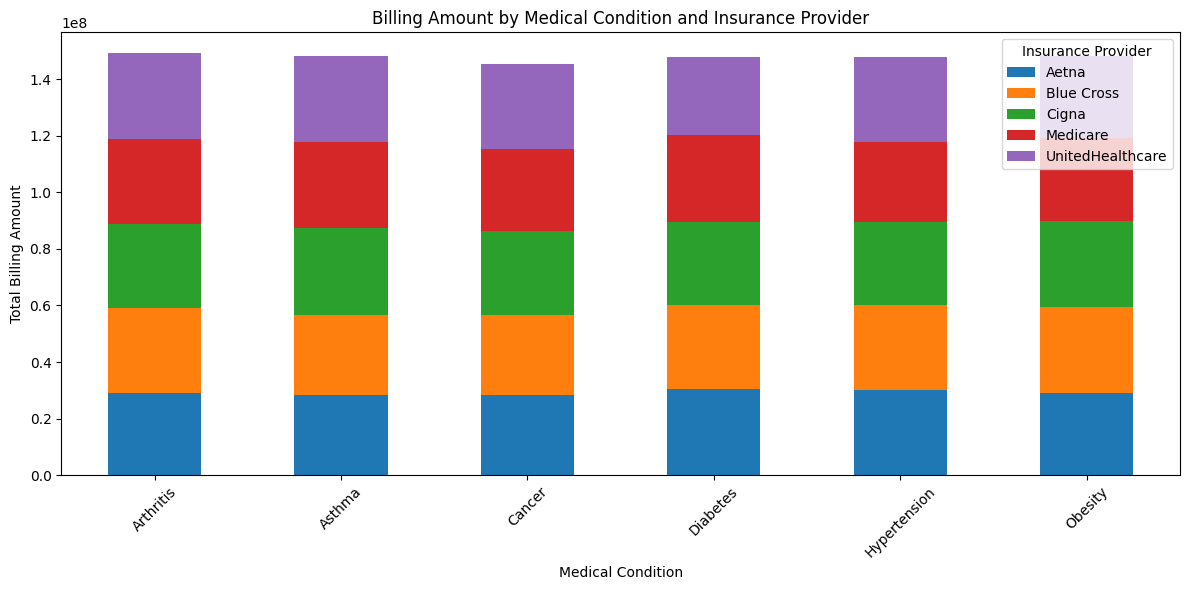

In [12]:

billing_data = df.groupby(
    ['Medical Condition', 'Insurance Provider']
)['Billing Amount'].sum().unstack(fill_value=0)


billing_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Billing Amount by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.tight_layout()
plt.show()

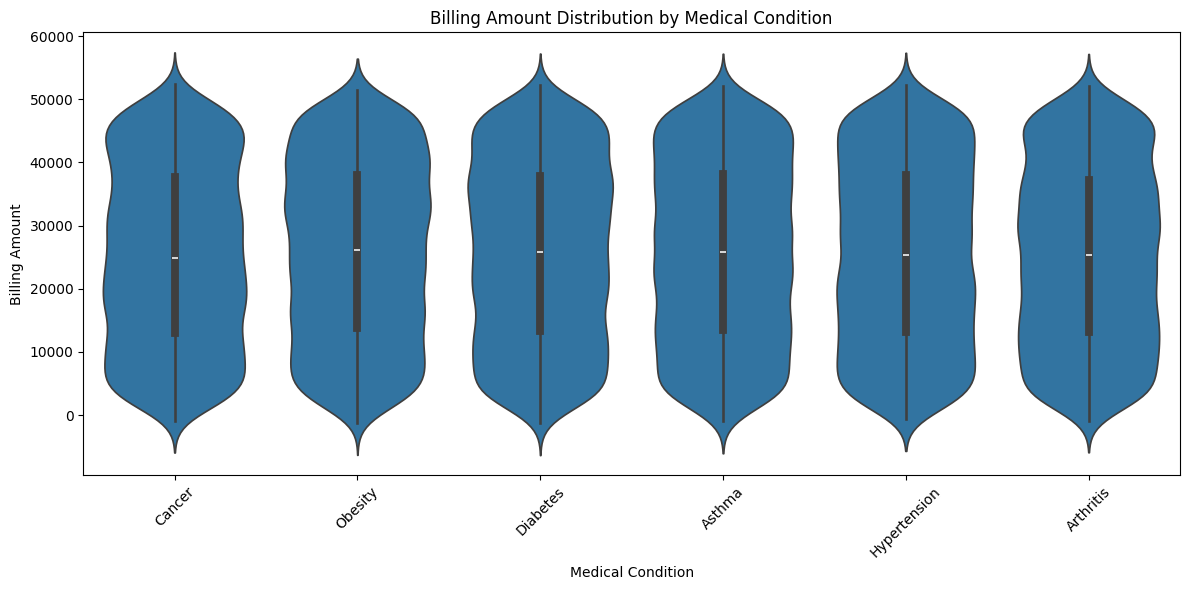

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

plt.title('Billing Amount Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

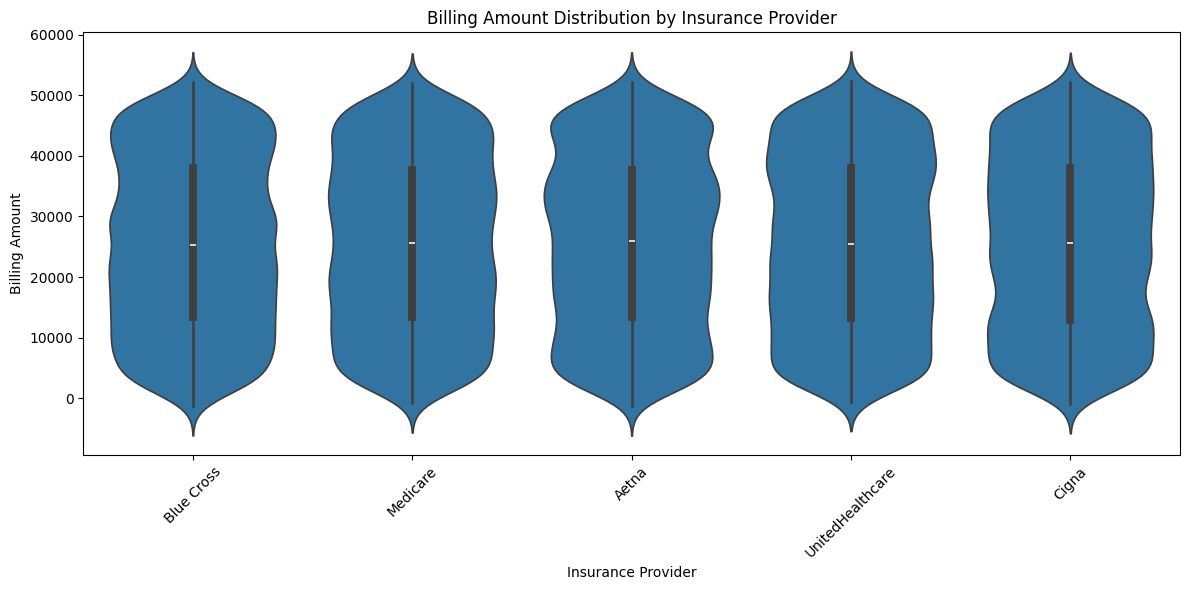

In [14]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount'
)

plt.title('Billing Amount Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print("Average Billing Amount by Medical Condition:")
print(df.groupby('Medical Condition')['Billing Amount'].mean())

print("\nAverage Billing Amount by Insurance Provider:")
print(df.groupby('Insurance Provider')['Billing Amount'].mean())

Average Billing Amount by Medical Condition:
Medical Condition
Arthritis       25360.210943
Asthma          25769.545773
Cancer          25277.092024
Diabetes        25761.146879
Hypertension    25516.713653
Obesity         25853.316596
Name: Billing Amount, dtype: float64

Average Billing Amount by Insurance Provider:
Insurance Provider
Aetna               25658.479965
Blue Cross          25542.696019
Cigna               25561.870423
Medicare            25605.990979
UnitedHealthcare    25574.502328
Name: Billing Amount, dtype: float64
